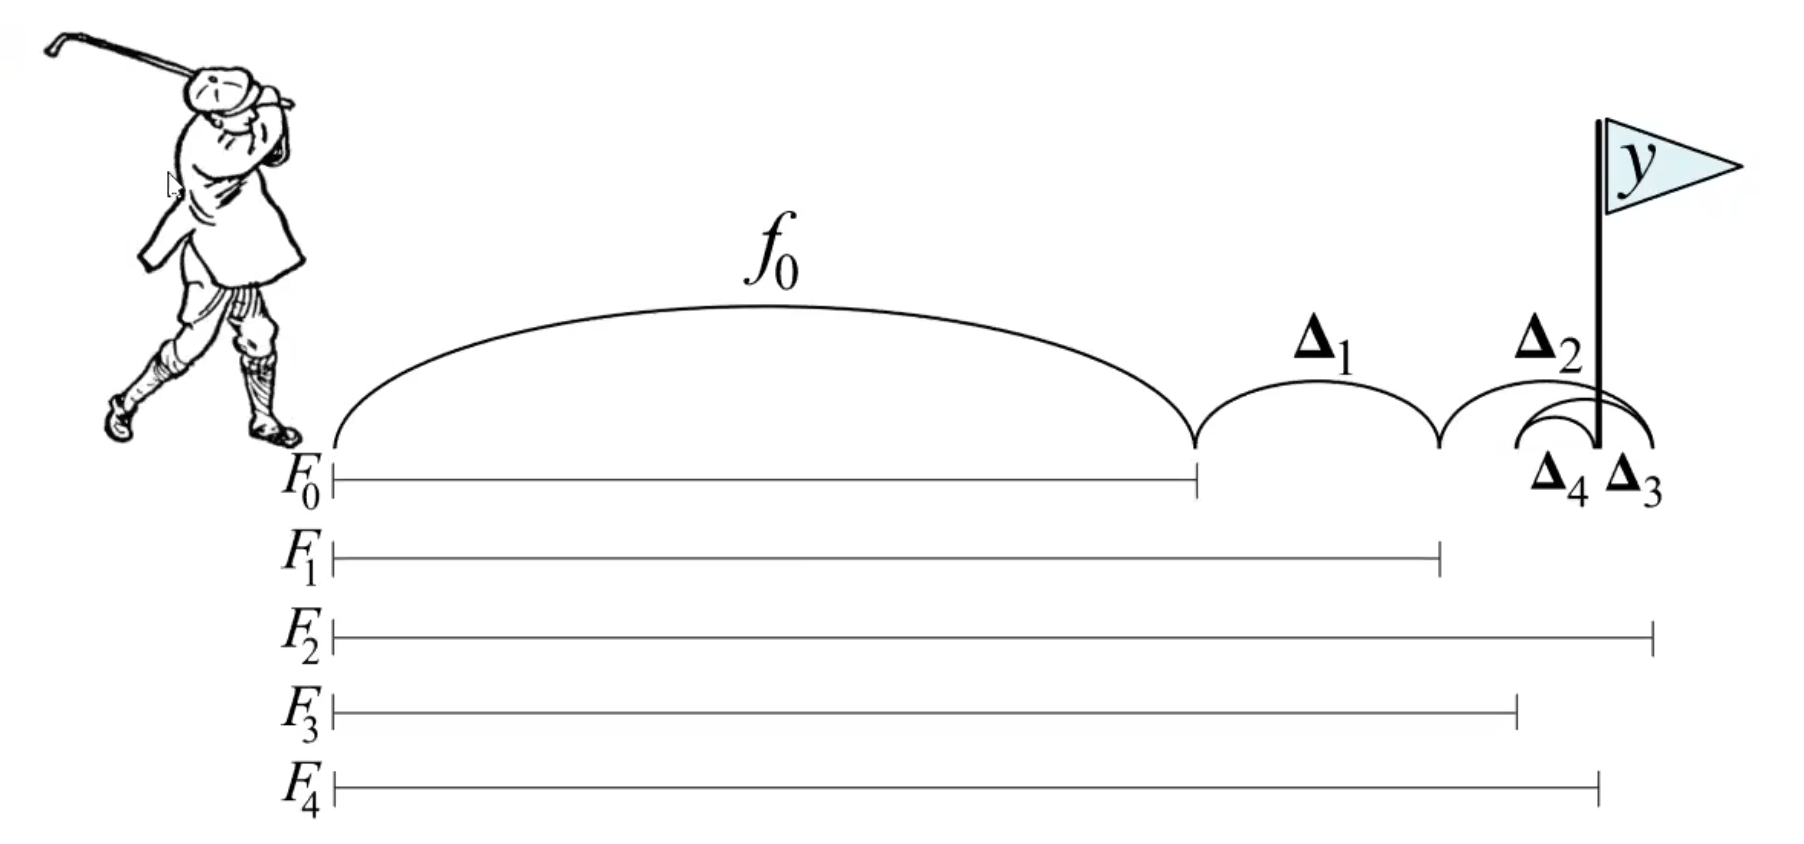

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [8]:
#Creating parabola type data    
X = np.linspace(-3, 3, 1000)
y = X**2 + np.random.randn(1000)

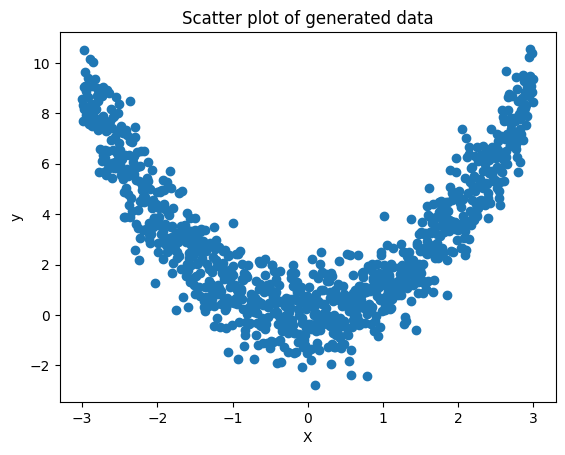

In [9]:
#Plotting the data
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter plot of generated data')
plt.show()

In [10]:
#Importing Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
#Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X.reshape(-1, 1), y, test_size=0.2, random_state=42)

In [11]:
#Creating and training the model for estimators as 1,2,3,...10
model = []
for n_estimators in range(1, 11):
    m = GradientBoostingRegressor(n_estimators=n_estimators, learning_rate=0.1, max_depth=3, random_state=42)
    m.fit(X_train, y_train)
    model.append(m)
    print(f'Model trained with {n_estimators} estimators.')

Model trained with 1 estimators.
Model trained with 2 estimators.
Model trained with 3 estimators.
Model trained with 4 estimators.
Model trained with 5 estimators.
Model trained with 6 estimators.
Model trained with 7 estimators.
Model trained with 8 estimators.
Model trained with 9 estimators.
Model trained with 10 estimators.


In [12]:
#Making predictions and evaluating the model with mse and r2 score for each model
from sklearn.metrics import mean_squared_error, r2_score
for i, m in enumerate(model, start=1):
    y_pred = m.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'Model with {i} estimators - MSE: {mse:.4f}, R2 Score: {r2:.4f}')

Model with 1 estimators - MSE: 6.9747, R2 Score: 0.1490
Model with 2 estimators - MSE: 5.9230, R2 Score: 0.2773
Model with 3 estimators - MSE: 5.0803, R2 Score: 0.3802
Model with 4 estimators - MSE: 4.3866, R2 Score: 0.4648
Model with 5 estimators - MSE: 3.7922, R2 Score: 0.5373
Model with 6 estimators - MSE: 3.3195, R2 Score: 0.5950
Model with 7 estimators - MSE: 2.9209, R2 Score: 0.6436
Model with 8 estimators - MSE: 2.5919, R2 Score: 0.6838
Model with 9 estimators - MSE: 2.2944, R2 Score: 0.7201
Model with 10 estimators - MSE: 2.0537, R2 Score: 0.7494


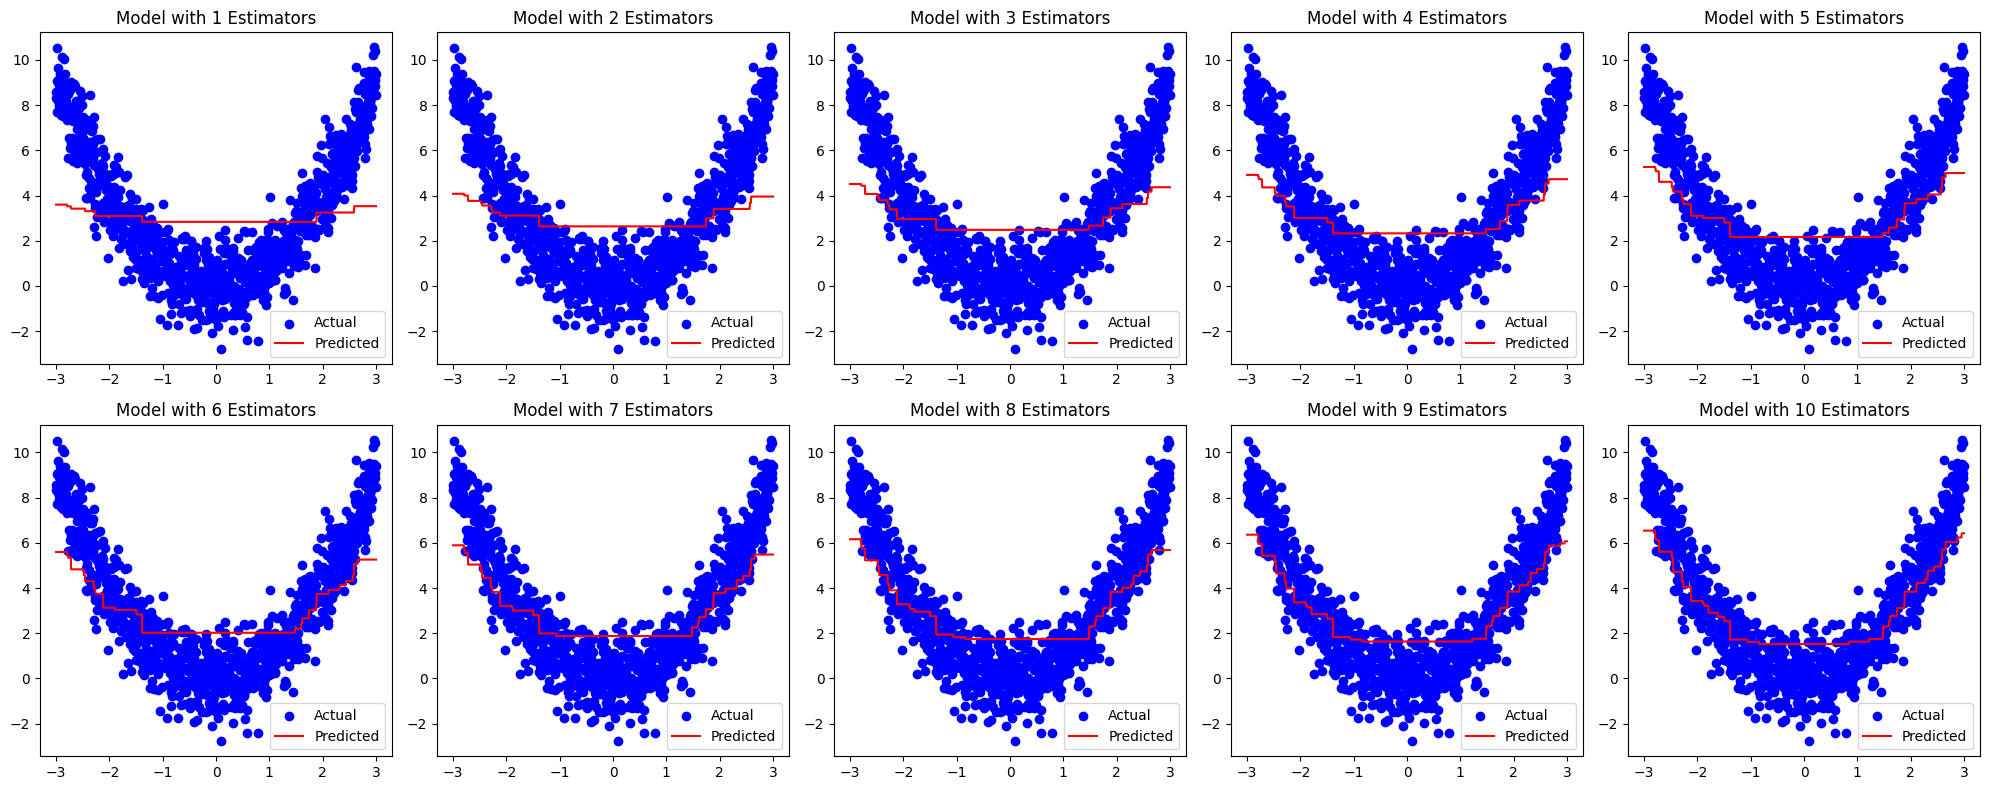

In [16]:
#The figures should be in grid format showing the predicted vs actual for each model where actual data is shown in blue and predicted line is shown in red.
X = np.linspace(-3, 3, 1000)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()
for i, m in enumerate(model):
    y_pred = m.predict(X.reshape(-1, 1))
    axes[i].scatter(X, y, color='blue', label='Actual')
    axes[i].plot(X, y_pred, color='red', label='Predicted')
    axes[i].set_title(f'Model with { (i+1) } Estimators')
    axes[i].legend()
plt.tight_layout()
plt.show()